In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
# from netCDF4 import Dataset
import sys

import cartopy.feature as cfeature
from matplotlib import cm

import cftime

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.


ERROR 1: PROJ: proj_create_from_database: Open of /home/m/m301254/.conda/envs/env02_waves/share/proj failed


----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


In [6]:
era5_oce = xr.open_dataset("/work/mh0033/m301254/proj_surfwave/icon-2026-06-ocean-era5/m301254/era5g-wave-forcing/build_intel/experiments/exp.ocean_era5_wave_R2B4L40/exp.ocean_era5_wave_R2B4L40_P1D_oce_era5_19850101T000000Z.nc")

In [7]:
# grid
gname_oce = 'r2b4_oce_r0004'
lev_oce = 'L40'

path_grid_oce = f'/home/m/m301254/pyicon_data/grids/{gname_oce}/'
fpath_tgrid = (f'{path_grid_oce}{gname_oce}_tgrid.nc')
fpath_ckdtree = (f'{path_grid_oce}ckdtree/rectgrids/r2b4_oce_r0004_res0.30_180W-180E_90S-90N.nc')

ds_tg = xr.open_dataset(fpath_tgrid)
ds_ckd = xr.open_dataset(fpath_ckdtree)

In [12]:
era5_oce

<xarray.Dataset> Size: 24MB
Dimensions:                (ncells: 15105, vertices: 3, time: 24)
Coordinates:
  * time                   (time) datetime64[ns] 192B 1985-01-02 ... 1985-01-...
    clon                   (ncells) float64 121kB ...
    clat                   (ncells) float64 121kB ...
Dimensions without coordinates: ncells, vertices
Data variables: (12/18)
    clon_bnds              (ncells, vertices) float64 363kB ...
    clat_bnds              (ncells, vertices) float64 363kB ...
    era5_t2m               (time, ncells) float32 1MB ...
    era5_tdew              (time, ncells) float32 1MB ...
    era5_wind10            (time, ncells) float32 1MB ...
    era5_ustress           (time, ncells) float32 1MB ...
    ...                     ...
    era5_runoff            (time, ncells) float32 1MB ...
    era5_slp               (time, ncells) float32 1MB ...
    era5_tcc               (time, ncells) float32 1MB ...
    era5_surf_ust          (time, ncells) float32 1MB ...
    era5_surf_vst          (time, ncells) float32 1MB ...
    era5_stokes_transport  (time, ncells) float32 1MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.6.0 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  36
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2026.04; revision: icon-2026.04-93-ge2eccc...
    history:              /work/mh0033/m301254/proj_surfwave/icon-2026-06-oce...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l20395 (Linux 4.18.0-553.125....

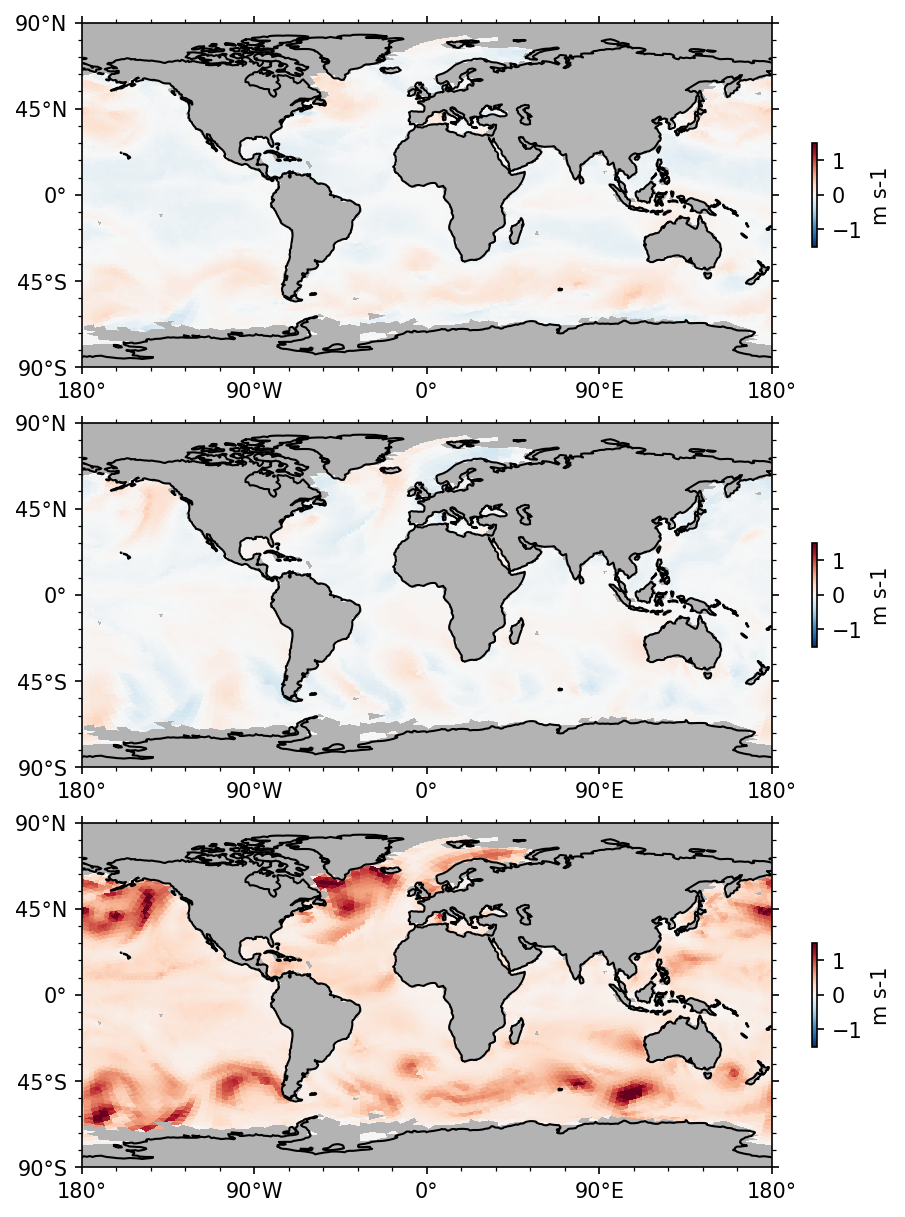

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(6,8),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            constrained_layout=True,
                            dpi=150,)
axes = axes.flatten()
mean_fields = [("era5_surf_ust", era5_oce["era5_surf_ust"].isel(time=20)),
               ("era5_surf_vst", era5_oce["era5_surf_vst"].isel(time=20)),
               ("era5_stokes_transport", era5_oce["era5_stokes_transport"].isel(time=20)),]
for ax, (title, mean) in zip(axes, mean_fields):
    ax, ct = mean.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid, 
        fpath_ckdtree=fpath_ckdtree,
        title_right="",
        land_facecolor="none",
        # cmap="Blues",
        clim=[-1.5,1.5],
        # use_pcol_or_contf=True,
        # conts=1.0,
        # lon_reg=[-95, -65],
        # lat_reg=[-25, 5],
        # plot_method="tgrid",
        )
    # ax.set_title(f"sp_10m climatology: {title}")
    fig.colorbar(ct[0], ax=ax, orientation="vertical", label="m s-1", pad=0.02, shrink=0.3)

plt.show()

In [11]:
# missing datapoints has no NaN but super big values
print(era5_oce["era5_surf_ust"].isel(time=1).max())
print(era5_oce["era5_surf_ust"].isel(time=1).min())
print('----')
print(era5_oce["era5_surf_vst"].isel(time=1).max())
print(era5_oce["era5_surf_vst"].isel(time=1).min())
print('----')
print(era5_oce["era5_stokes_transport"].isel(time=1).max())
print(era5_oce["era5_stokes_transport"].isel(time=1).min())


<xarray.DataArray 'era5_surf_ust' ()> Size: 4B
array(0.48201936, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00
<xarray.DataArray 'era5_surf_ust' ()> Size: 4B
array(-0.5083187, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00
----
<xarray.DataArray 'era5_surf_vst' ()> Size: 4B
array(0.43303636, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00
<xarray.DataArray 'era5_surf_vst' ()> Size: 4B
array(-0.3930802, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00
----
<xarray.DataArray 'era5_stokes_transport' ()> Size: 4B
array(2.6579056, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00
<xarray.DataArray 'era5_stokes_transport' ()> Size: 4B
array(0., dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1985-01-01T01:00:00


In [26]:
# find the mask where values are zero
mask1 = era5_oce["era5_surf_ust"].isel(time=1) == 0
mask2 = era5_oce["era5_surf_vst"].isel(time=1) == 0
mask3 = era5_oce["era5_stokes_transport"].isel(time=1) == 0

Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.
Deriving triangulation object, this can take a while...
Done deriving triangulation object.


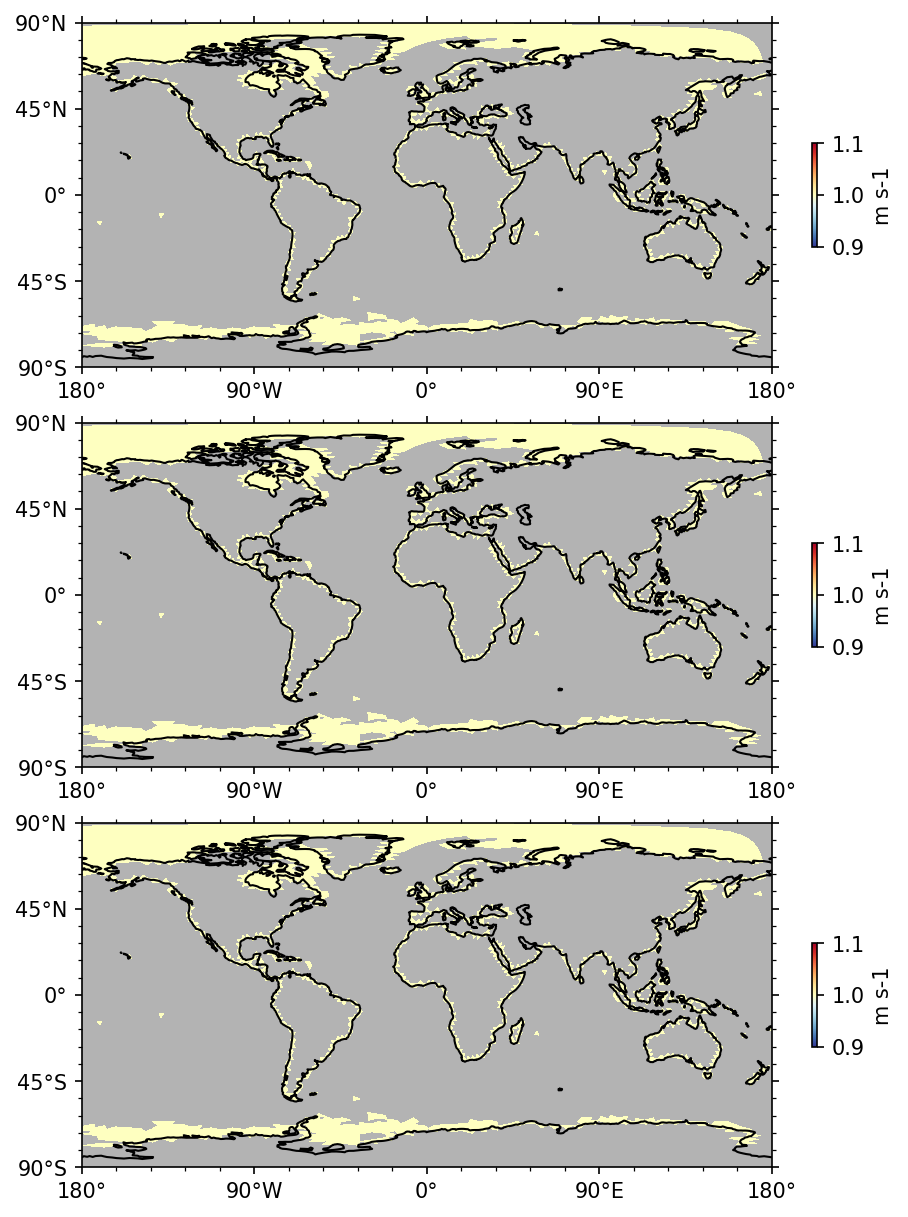

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(6,8),
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            constrained_layout=True,
                            dpi=150,)
ax = axes.flatten()
mean_fields = [("Null_mask_ust", mask1),
               ("Null_mask_vst", mask2),
               ("Null_mask_transport", mask3)]
for ax, (title, mean) in zip(axes, mean_fields):
    ax, ct = mean.pyic.plot(
        ax=ax, cax=0,
        fpath_tgrid=fpath_tgrid, 
        fpath_ckdtree=fpath_ckdtree,
        title_right="",
        land_facecolor="none",
        # cmap="Blues",
        # clim=[-1,1],
        # use_pcol_or_contf=True,
        # conts=1.0,
        # lon_reg=[-95, -65],
        # lat_reg=[-25, 5],
        plot_method="tgrid",
        )
    # ax.set_title(f"sp_10m climatology: {title}")
    fig.colorbar(ct[0], ax=ax, orientation="vertical", label="m s-1", pad=0.02, shrink=0.3)

plt.show()